In [161]:
import pandas

In [162]:
df = pandas.read_json('json/grammies.json')

In [163]:
df = df[['annual_edition', 'year', 'award', 'artist', 'artist_link', 'producers', 'song_or_album', 'url', 'winner']]

In [188]:
df.shape

(25043, 9)

In [164]:
df = df.astype({'year': 'Int64', 'annual_edition': 'Int64', 'winner': 'bool'})

The latest iterations of the page do not include the year but include the edition as starting number for the title

In [165]:
def set_year(value: int):
    if value == 66:
        return 2023
    
    if value == 65:
        return 2022
    
    if value == 64:
        return 2021

    if value == 67:
        return 2024

    return value

In [166]:
df['year'] = df.year.map(set_year)

In [167]:
df.sort_values(by=['year', 'award'], inplace=True)

## Data Exploration

In [168]:
from matplotlib import pyplot as plt

In [169]:
grouping = df.groupby('year')['year'].count()

## Count of winners vs Losers

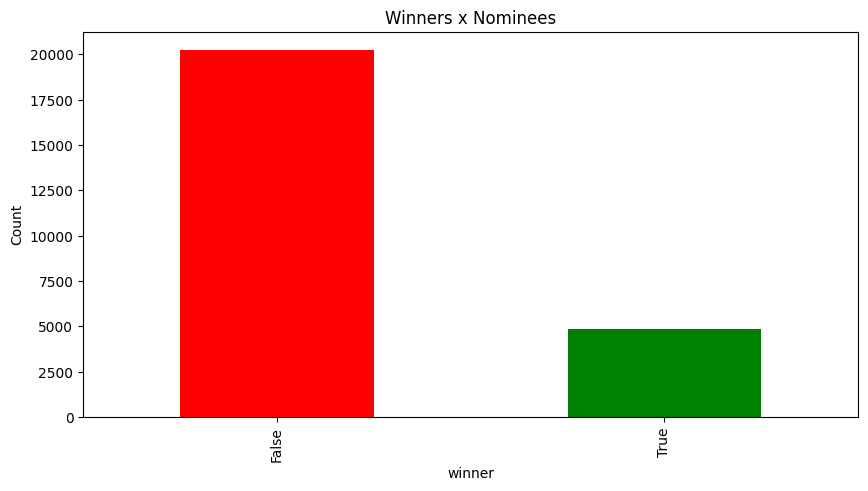

In [199]:
plt.figure(figsize=(10, 5))

plt.title('Winners x Nominees')

plt.ylabel('Count')
plt.xlabel('Result')

plt.grid(axis='y', linestyle='--', alpha=0.7)

winners_x_nominees = df.groupby('winner')['winner'].count()
winners_x_nominees.plot(kind='bar', color=['red', 'green'])

plt.show()

## Number of entries per year

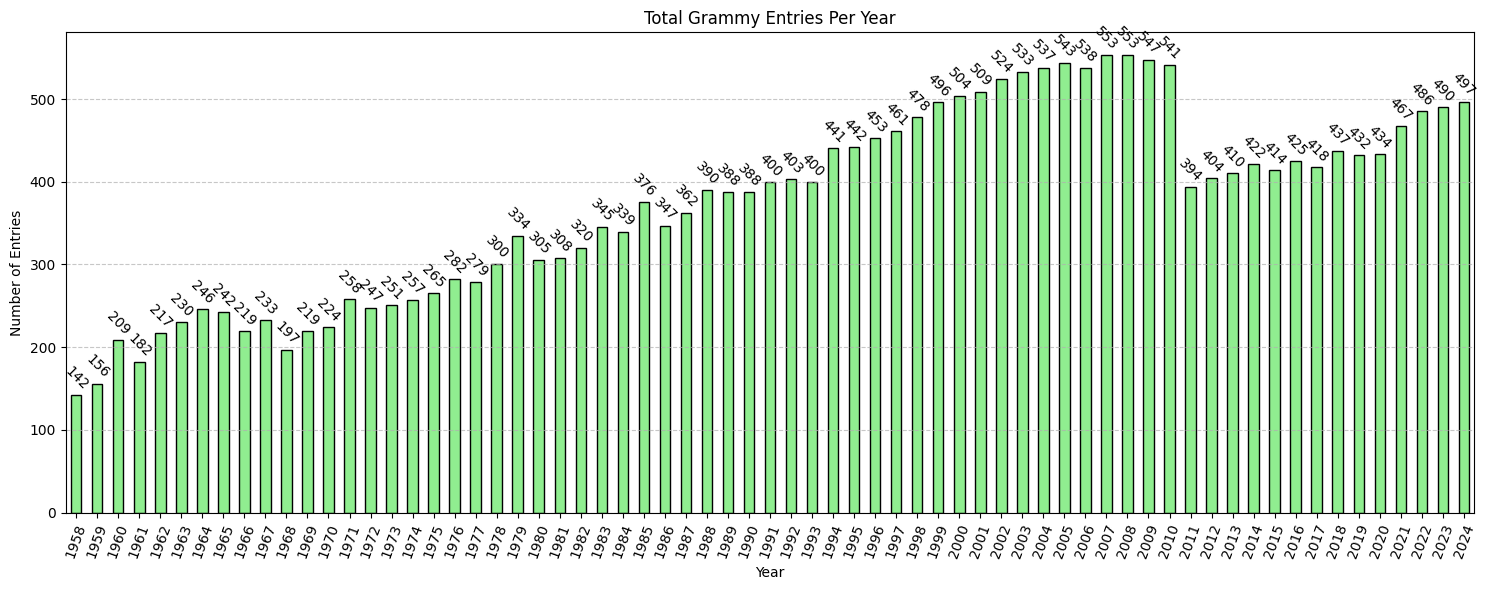

In [170]:
plt.figure(figsize=(15, 6))

ax = grouping.plot(kind='bar', color='lightgreen', edgecolor='black')

plt.title('Total Grammy Entries Per Year')


plt.xlabel('Year')
plt.ylabel('Number of Entries')
plt.xticks(rotation=70)
plt.grid(axis='y', linestyle='--', alpha=0.7)

params = {'ha': 'center', 'va': 'center', 'rotation': -45}

for p in ax.patches:
    height = p.get_height()
    x = p.get_x() + p.get_width() / 2
    y = height + 20
    ax.text(x, y, f'{int(height)}', **params)

plt.tight_layout()
plt.show()

In [171]:
category_df = df[['year', 'annual_edition', 'award']].drop_duplicates(['award'])
category_by_year = category_df.groupby('year')['award'].count()

In [172]:
category_df.head(n=5)

,year,annual_edition,award
20203,1958,1,Album Of The Year
20275,1958,1,Best Album Cover
20261,1958,1,Best Arrangement
20324,1958,1,Best Classical Performance - Chamber Music (In...
20319,1958,1,Best Classical Performance - Instrumentalist (...


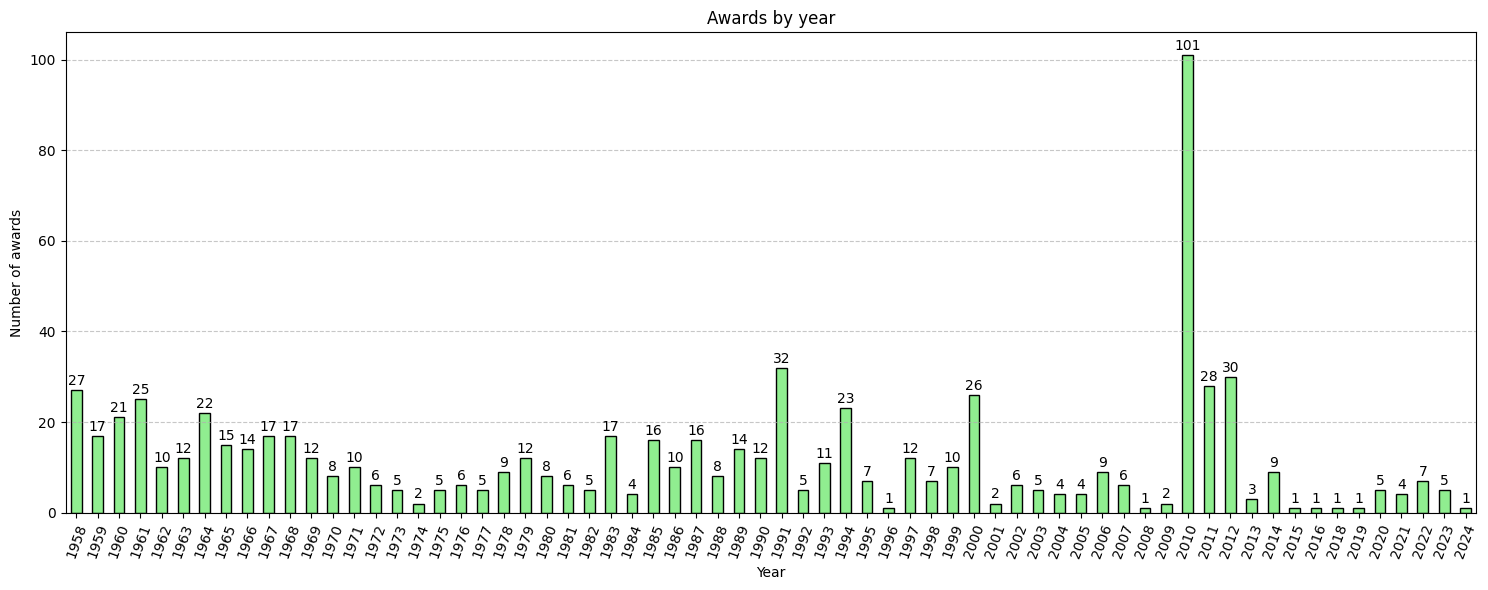

In [173]:
plt.figure(figsize=(15, 6))

ax = category_by_year.plot(kind='bar', color='lightgreen', edgecolor='black')

plt.title('Awards by year')

plt.xlabel('Year')
plt.ylabel('Number of awards')

plt.xticks(rotation=70)
plt.grid(axis='y', linestyle='--', alpha=0.7)

params = {'ha': 'center', 'va': 'center'}

for p in ax.patches:
    height = p.get_height()
    x = p.get_x() + p.get_width() / 2
    y = height + 2
    ax.text(x, y, f'{int(height)}', **params)

plt.tight_layout()
plt.show()

In [200]:
winners = df[df.winner == True]
winners_by_year = winners.groupby('year')['artist'].count()

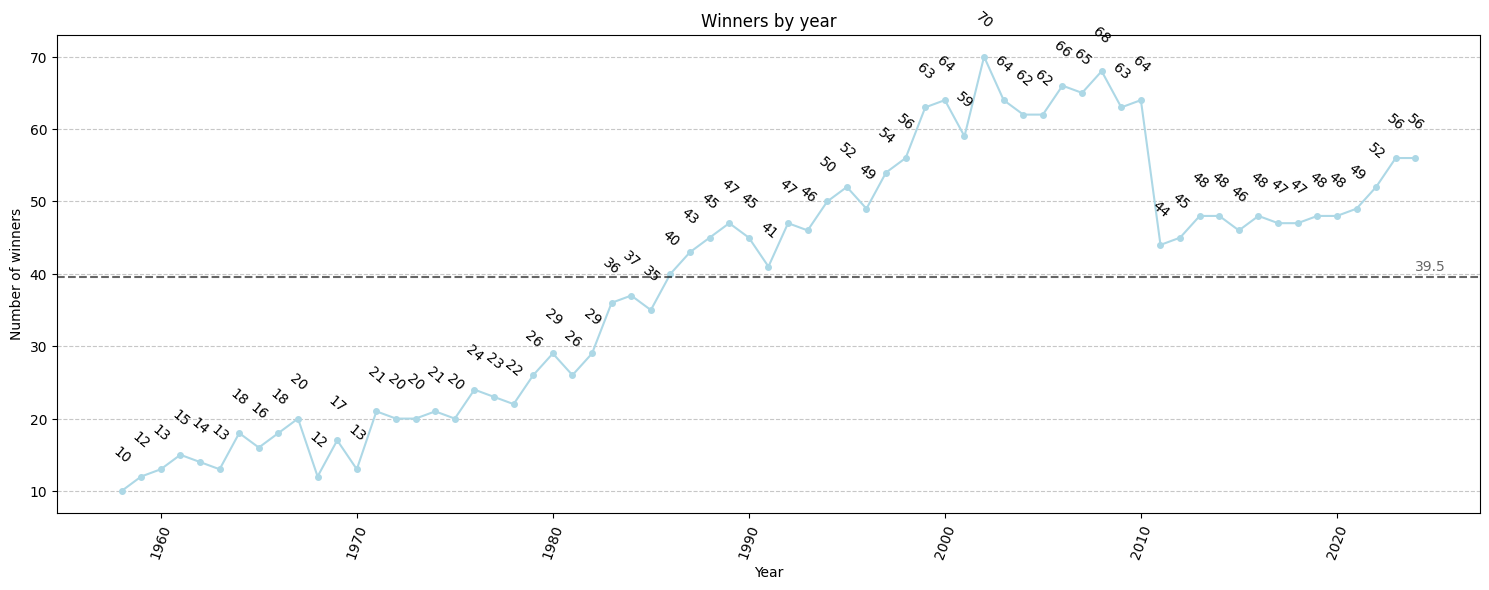

In [ ]:
plt.figure(figsize=(15, 6))

ax = winners_by_year.plot(kind='line', color='lightblue', marker='o', markersize=4)

plt.title('Winners by year')

plt.xlabel('Year')
plt.ylabel('Number of winners')

plt.xticks(rotation=70)
plt.grid(axis='y', linestyle='--', alpha=0.7)

params = {'ha': 'center', 'va': 'center', 'rotation': -40}

for x, y in zip(winners_by_year.index, winners_by_year.values):
    ax.text(x, y + 5, f'{int(y)}', **params)


# Calculate average
avg_winners = winners_by_year.mean()
ax.axhline(y=avg_winners, color='black', linestyle='--', alpha=0.6, linewidth=1.5, label='Average')

x_pos = winners_by_year.index[-1]
ax.text(x_pos, avg_winners + 0.5, f'{avg_winners:.1f}', color='black', alpha=0.6, fontsize=10, ha='left', va='bottom')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

plt.show()

In [174]:
df.to_csv('grammies_v4.csv', index=False)

## Add categories

In [175]:
awards_df = df[['award']].drop_duplicates()

In [176]:
def is_album(inner_df: pandas.DataFrame) -> pandas.DataFrame:
    inner_df['is_album'] = inner_df['award'].str.contains('Album', case=False, na=False)
    return inner_df

In [177]:
def is_song(inner_df: pandas.DataFrame) -> pandas.DataFrame:
    inner_df['is_song'] = inner_df['award'].str.contains('Song', case=False, na=False)
    return inner_df

In [178]:
def is_new_artist(inner_df: pandas.DataFrame) -> pandas.DataFrame:
    inner_df['is_artist'] = inner_df['award'].str.contains('New Artist', case=False, na=False) | inner_df['award'].str.contains('Artist', case=False, na=False)
    return inner_df

In [179]:
# def is_single(inner_df: pandas.DataFrame) -> pandas.DataFrame:
#     inner_df['is_single'] = inner_df['award'].str.contains('Single', case=False, na=False)
#     return inner_df

In [180]:
awards_df.pipe(is_album).pipe(is_song).pipe(is_new_artist)

,award,is_album,is_song,is_artist
20203,Album Of The Year,True,False,False
20275,Best Album Cover,True,False,False
20261,Best Arrangement,False,False,False
20324,Best Classical Performance - Chamber Music (In...,False,False,False
20319,Best Classical Performance - Instrumentalist (...,False,False,False
...,...,...,...,...
8906,Best Alternative Jazz Album,True,False,False
8881,Best Jazz Performance,False,False,False
9035,Best Música Mexicana Album (Including Tejano),True,False,False
8791,Best Pop Dance Recording,False,False,False


## Artists

In [185]:
artists_df = df[['artist', 'artist_link']].drop_duplicates()

In [186]:
artists_df.sort_values(by=['artist'], inplace=True)

In [187]:
artists_df.to_csv('artists.csv', index=False)

In [184]:
awards_df.to_csv('categories.csv', index=False)